### Binary Traffic Sign Classification

This is our first notebook on neural networks. We will start by building a simple neural network that will help us to classify two types of traffic signs. The signs used in this lesson are a processed subset from the famous German Traffic Sign Recognition Database (GTSRB) that can be downloaded [here]().

In [2]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]

#### Data Loading

Let's now load the data to see what we are dealing with.

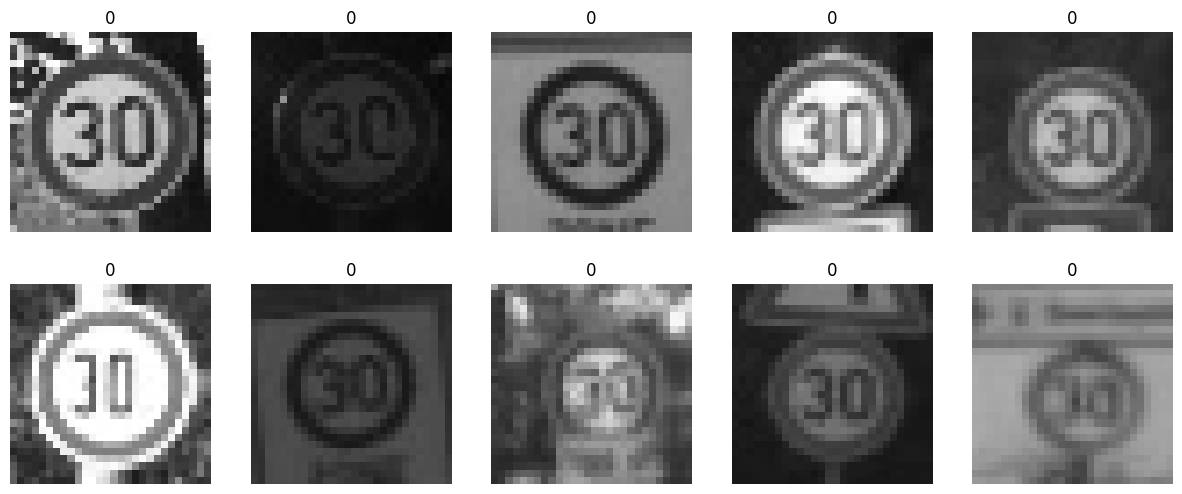

In [48]:
folder = '../data/subset_homework_v2'

# Load traffic sign class 0
fnames_0 = os.listdir(os.path.join(folder, 'class_id_0'))
images_0 = [cv2.imread(os.path.join(folder, 'class_id_0', f), cv2.IMREAD_UNCHANGED) for f in fnames_0]
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

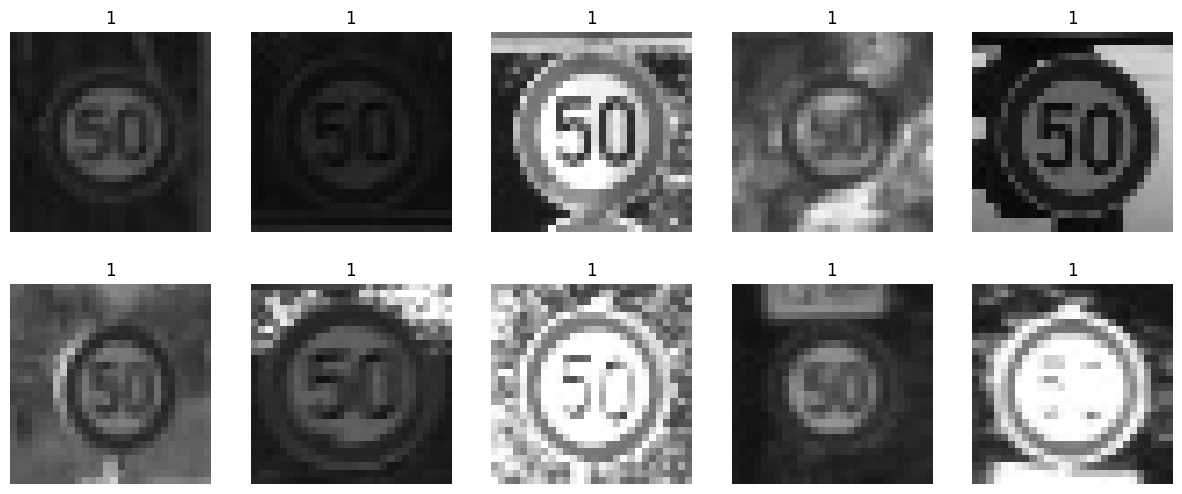

In [50]:
# Load traffic sign class 1
fnames_1 = os.listdir(os.path.join(folder, 'class_id_1'))
images_1 = [cv2.imread(os.path.join(folder, 'class_id_1', f), cv2.IMREAD_UNCHANGED) for f in fnames_1]
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

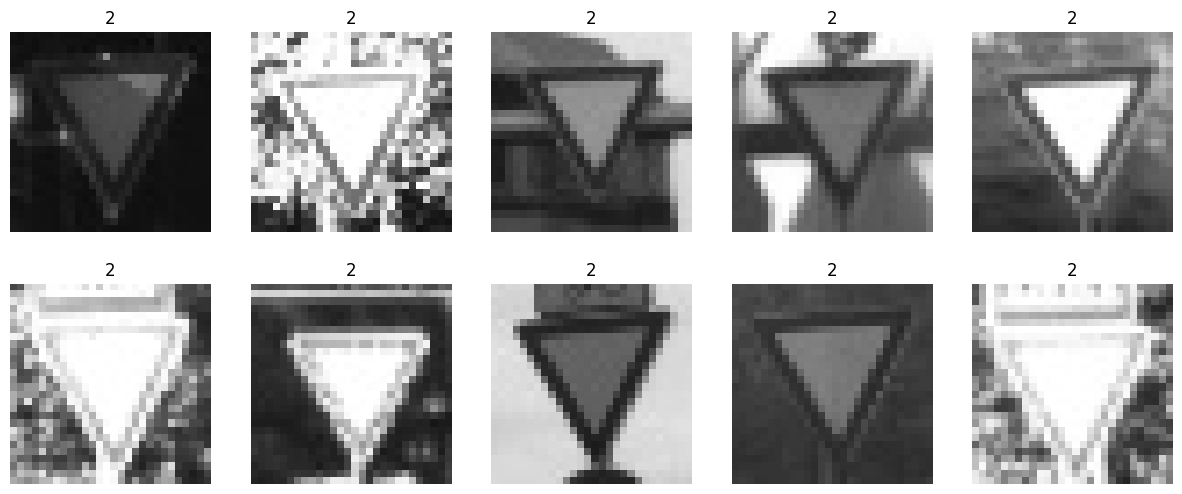

In [52]:
# Load traffic sign class 2
fnames_2 = os.listdir(os.path.join(folder, 'class_id_2'))
images_2 = [cv2.imread(os.path.join(folder, 'class_id_2', f), cv2.IMREAD_UNCHANGED) for f in fnames_2]
labels_2 = [2] * len(images_2)

for cnt, idx in enumerate(np.random.randint(0, len(images_2), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_2[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_2[idx]), plt.axis(False)

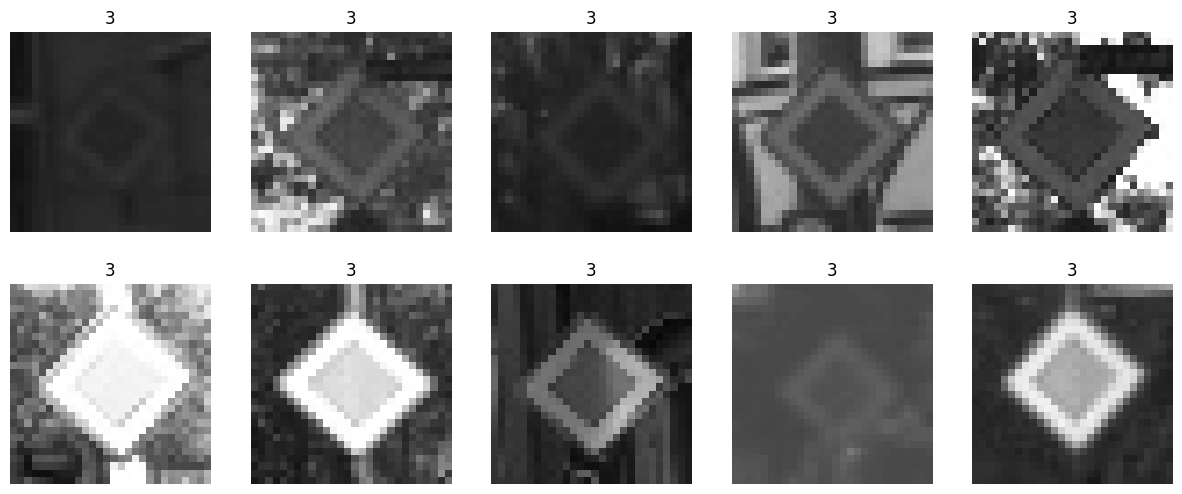

In [54]:
# Load traffic sign class 3
fnames_3 = os.listdir(os.path.join(folder, 'class_id_3'))
images_3 = [cv2.imread(os.path.join(folder, 'class_id_3', f), cv2.IMREAD_UNCHANGED) for f in fnames_3]
labels_3 = [3] * len(images_3)

for cnt, idx in enumerate(np.random.randint(0, len(images_3), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_3[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_3[idx]), plt.axis(False)

In [56]:
print('Num samples class_0', len(images_0))
print('Num samples class_1', len(images_1))
print('Num samples class_2', len(images_2))
print('Num samples class_3', len(images_3))

Num samples class_0 2220
Num samples class_1 2250
Num samples class_2 2160
Num samples class_3 2100


#### Prepare Input Data

To train our neural network model, we have to prepare the data to the format the the model actually expects. In our case, this will be numpy arrays.

In [59]:
# Put both classes together and shuffle  the data
images = images_0 + images_1 + images_2 + images_3
labels = labels_0 + labels_1 + labels_2 + labels_3
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (8730, 28, 28)
Labels (8730,)


But now we have a problem. We cannot just feed the image to a neuron since the neuron inputs are flat (one dimensional). On the other hand, the images are 2D matrices. Therefore, we need to "flatten" the images to a one dimensional vector of pixels.

In [62]:
start = time()
pixels = []
for image in images:
    pixels_ = []
    for r in range(image.shape[0]):
        for c in range(image.shape[1]):
            pixels_.append(image[r,c])
    pixels.append(pixels_)
    
pixels = np.array(pixels)/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (8730, 784)
Elapsed time 1.774595022201538


Or, you know, just let make use of our friend numpy :-)

In [65]:
start = time()
pixels = np.array([image.flatten() for image in images])/255
stop = time()

print('Shape', pixels.shape)
print('Elapsed time', stop - start)

Shape (8730, 784)
Elapsed time 0.06329607963562012


Before the training, let's again have a look at some raqndom samples from our dataset.

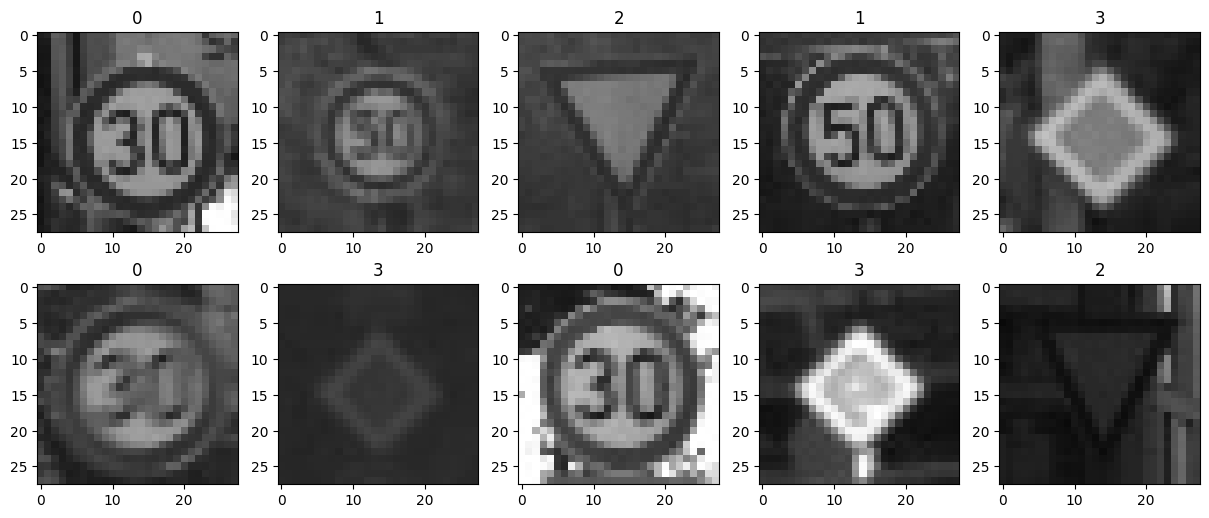

In [68]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

#### Building the Neural Network

Let's now build our first (and yes, very simple) neural network using Tensorflow. For that, we will need a couple of new imports.

In [72]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

The following netowork will consist of only one single neuron. It is a very tiny network (not even a network, strictly speaking :-) ) and yet it can be quite powerful.

In [74]:
inputs = Input(shape=(pixels.shape[1],))

# Приховані шари
x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)

# Вихідний шар — 4 класи
outputs = Dense(4, activation='softmax')(x)

# Створюємо модель
model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,996 (425.77 KB)

 Trainable params: 108,996 (425.77 KB)

 Non-trainable params: 0 (0.00 B)

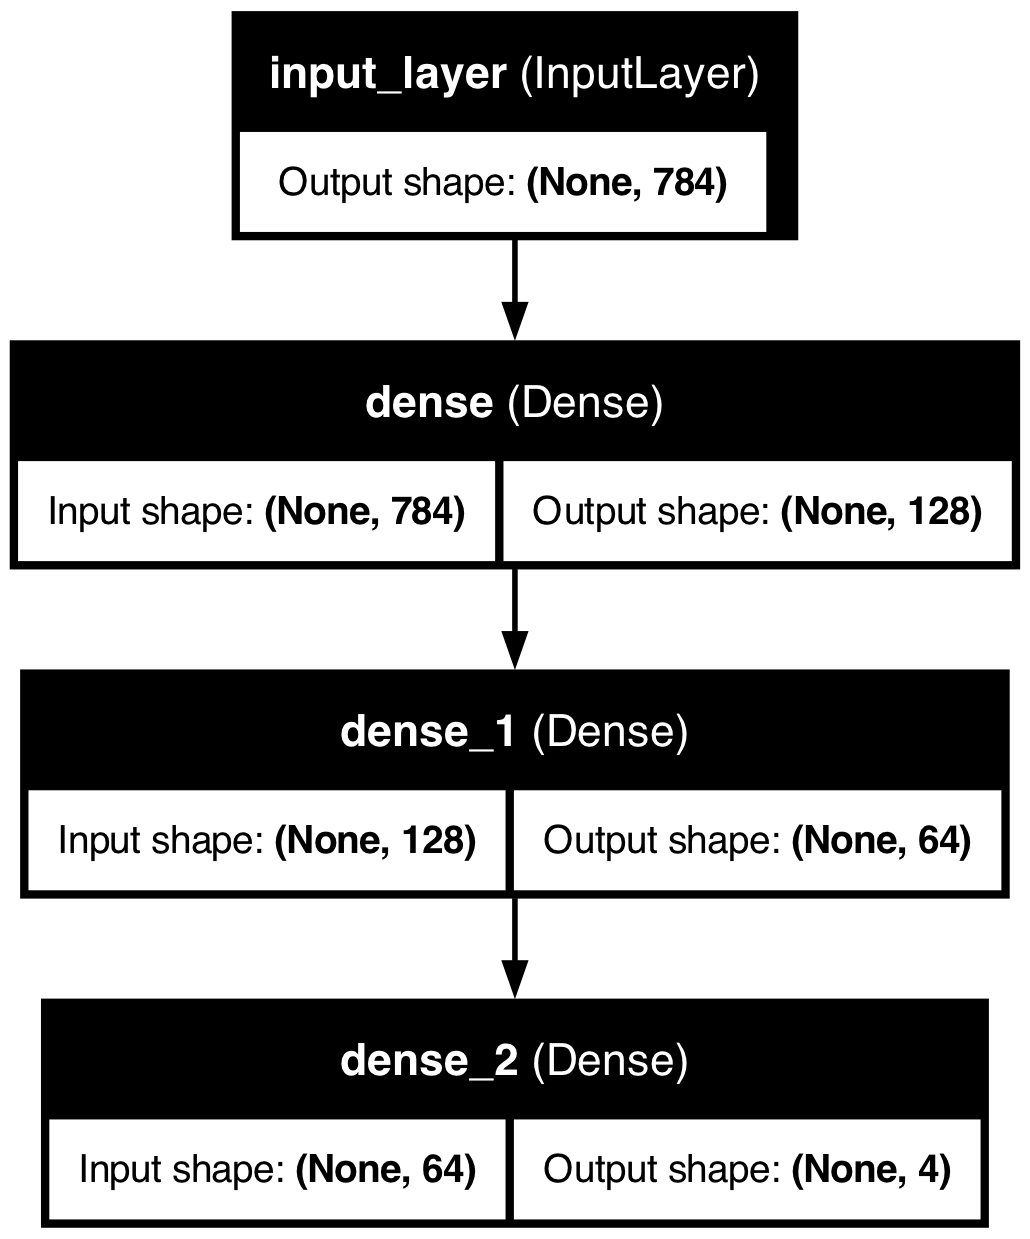

In [76]:
tf.keras.utils.plot_model(model, to_file="model_homework_v3.png", show_shapes=True, show_layer_names=True)

Before starting the training, we have to compile the model. During the compilation, we indicate what optimizer we want to use and what loss should be applied for the minimization process.

In [84]:
#Оскільки це багатокласова класифікація, потрібно змінити функцію втрат і метрику
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # або categorical_crossentropy, якщо y в one-hot форматі
    metrics=['accuracy']
)

In [86]:
labels

array([0, 0, 2, ..., 1, 2, 3])

And let's train :-)

In [88]:
history = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6845 - loss: 0.8159
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8564 - loss: 0.4295
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8897 - loss: 0.3245
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9236 - loss: 0.2415
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9337 - loss: 0.2100
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9419 - loss: 0.1856
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9497 - loss: 0.1597
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9449 - loss: 0.1639
Epoch 9/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9471 - loss: 0.1636
Epoch 10/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9512 - loss: 0.1495


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

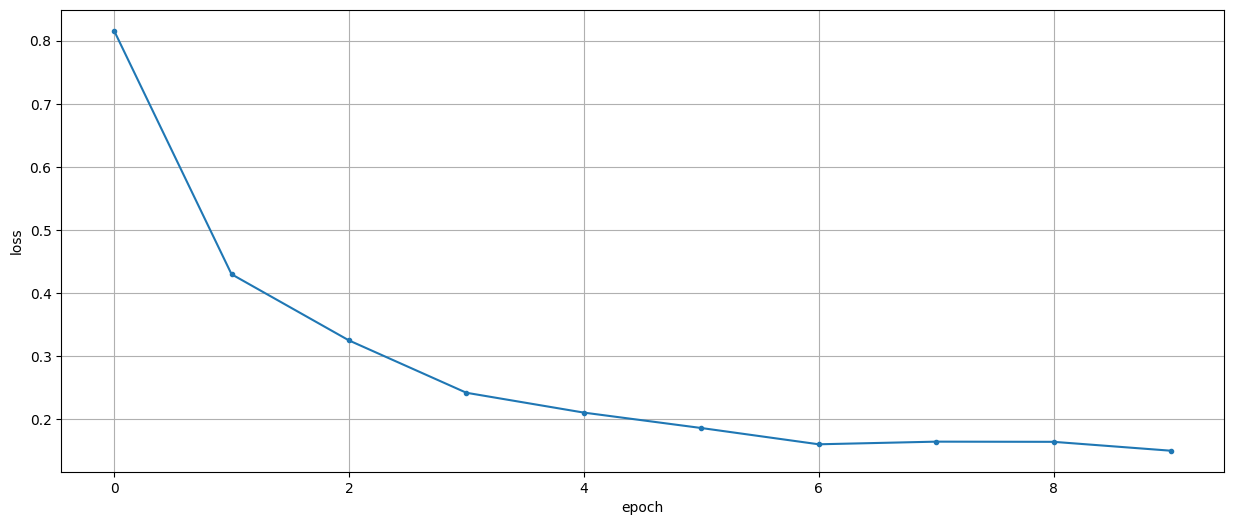

In [90]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[-0.00805578  0.04472588  0.05012186 -0.00558639 -0.05579233  0.02813784
  0.12074222 -0.00629189 -0.00979944  0.08597956 -0.00252249 -0.00508895
 -0.00296215  0.07528234 -0.00512294  0.03945385 -0.04068599 -0.00455467
 -0.00600124 -0.04630017  0.01916082  0.17807789  0.00112576  0.10323323
 -0.05263209 -0.00741183  0.02818443 -0.00188389 -0.00541256 -0.00849851
 -0.00055785 -0.00458578  0.          0.10319772 -0.00705188 -0.00725061
  0.         -0.00811614 -0.01085383  0.06451333 -0.00535368 -0.00476559
  0.02017121  0.00234622 -0.00932473  0.0008347  -0.00557988  0.08183117
 -0.00450932 -0.06006442 -0.0059886  -0.00514414 -0.00868504 -0.01179778
  0.08846816  0.12378091 -0.00963362 -0.00639974  0.11149216  0.10895468
 -0.00497402 -0.02877357  0.05725962  0.00434712  0.12543805  0.09752482
 -0.00452386  0.         -0.00856128  0.06694234  0.0202378   0.06260239
  0.1772748  -0.00602153  0.0060543   0.02409928  0.          0.09603731
  0.07791203  0.03853866 -0.00351923  0.13916197  0

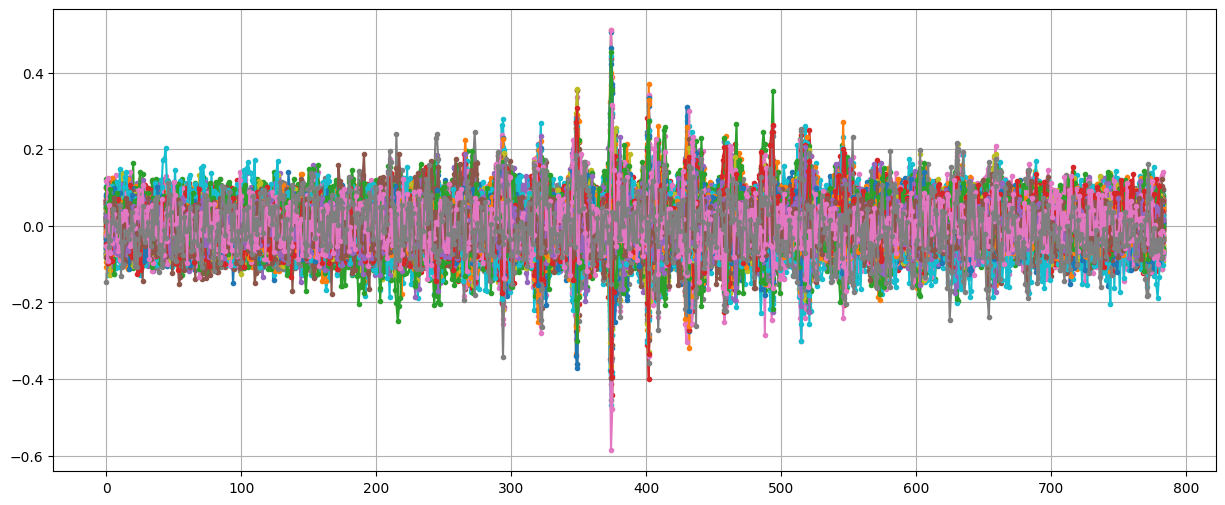

In [92]:
# Let's also have a looks at the learnt weights
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

#### Performance Evaluation

Once our model is trained, we will can run it on our images to see how it performs (inference).

In [95]:
idx = 78
pred = model.predict(pixels[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[8.2504522e-07 9.9999917e-01 7.3588783e-12 4.0519229e-12]] 1


In [97]:
# Run it on the entire dataset
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step


In [101]:
correct = 0
for prediction, label in zip(predictions, labels):
    predicted_class = np.argmax(prediction)  # індекс найбільшого значення
    if predicted_class == label:
        correct += 1

print('Accuracy', correct / len(labels))

Accuracy 0.8864833906071019


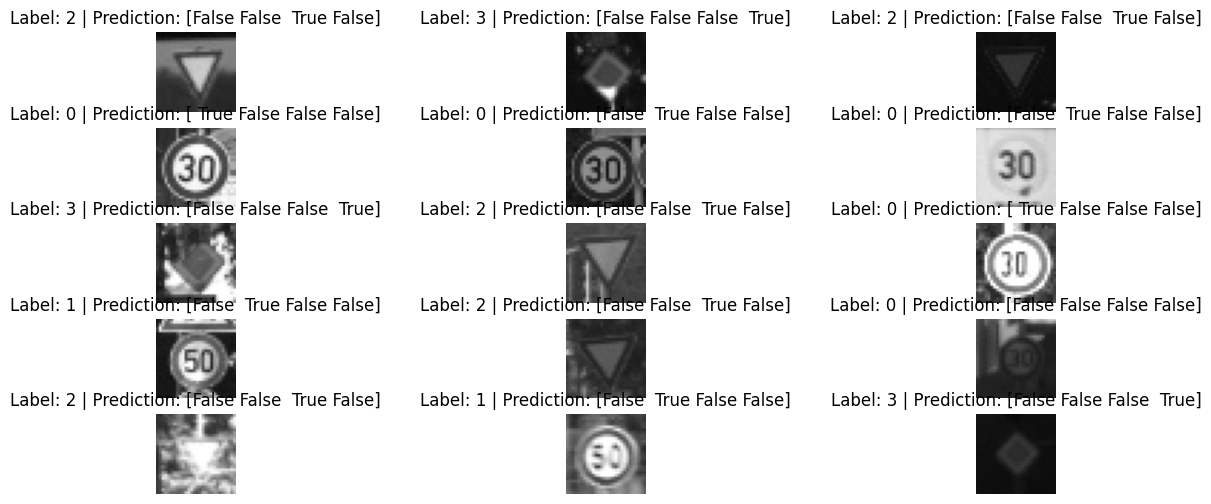

In [105]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 15)): 
    plt.subplot(5,3,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)